<a href="https://colab.research.google.com/github/Suraj-Kumar09/EDA_For_AI-Machine_Learning/blob/main/Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Suraj")

Suraj


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
import seaborn as sns


In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hereaadrika/householdsales-2007-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'householdsales-2007-2019' dataset.
Path to dataset files: /kaggle/input/householdsales-2007-2019


In [8]:
import os
print(os.listdir(path))

['raw_sales.csv', '.nfs000000003cf28f0a000000e4']


In [9]:
df = pd.read_csv("/kaggle/input/householdsales-2007-2019/raw_sales.csv")

In [10]:
df.head(5)

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [11]:
df.isnull().sum()

,0
datesold,0
postcode,0
price,0
propertyType,0
bedrooms,0


In [12]:
df.describe()

,postcode,price,bedrooms
count,29580.000000,2.958000e+04,29580.000000
mean,2730.249730,6.097363e+05,3.250169
std,146.717292,2.817079e+05,0.951275
min,2600.000000,5.650000e+04,0.000000
25%,2607.000000,4.400000e+05,3.000000
50%,2615.000000,5.500000e+05,3.000000
75%,2905.000000,7.050000e+05,4.000000
max,2914.000000,8.000000e+06,5.000000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

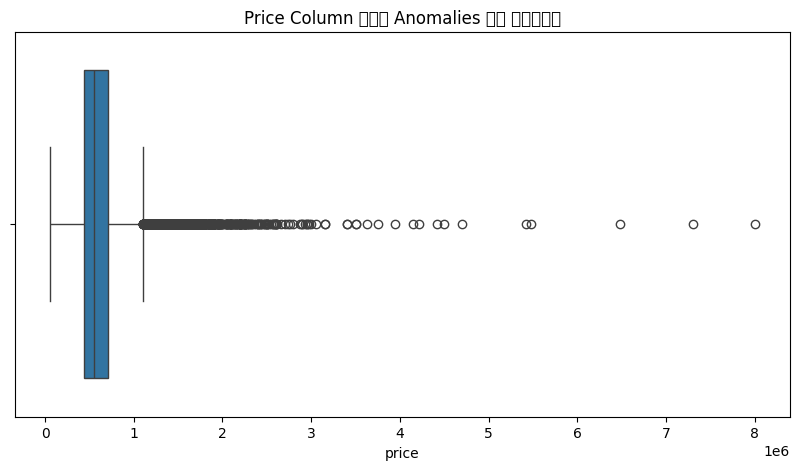

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Price Column में Anomalies की पहचान')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib

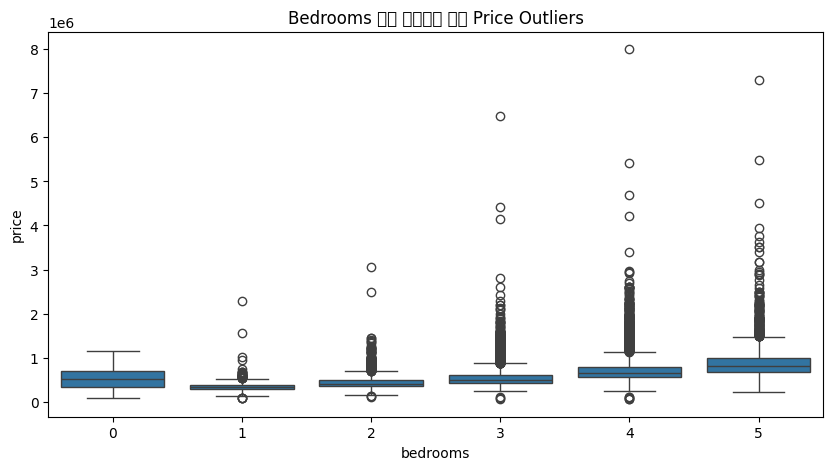

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Bedrooms के आधार पर Price Outliers')
plt.show()

In [15]:
def find_anomalies(df):
  anomalies = []


  # Set upper and lower limit to 3 standard deviations. (Boxplot nikalne ke liy)
  random_data_std = statistics.stdev(df)
  random_data_mean = statistics.mean(df)

  # 3 statics deviations

  anomaly_cut_off = random_data_std * 3

  lower_limit = random_data_mean - anomaly_cut_off
  upper_limit = random_data_mean + anomaly_cut_off

  # general outliers
  for outliers in df:
    if outliers > upper_limit or outliers < lower_limit:
      anomalies.append(outliers)
  return anomalies

In [16]:
df.price

,price
0,525000
1,290000
2,328000
3,380000
4,310000
...,...
29575,500000
29576,560000
29577,464950
29578,589000


In [17]:
list_1 = find_anomalies(df.price)

In [18]:
len(list_1)

461

In [19]:
len(df)

29580

How to find anomaly(outlirs) = len(list_1) / len(df) * 100

anomaly = 461/29580 *100


anomaly = 1.55%

In [20]:
df.price.skew() # How many data is skewed.

np.float64(4.312009366902366)

<Axes: xlabel='price', ylabel='Density'>

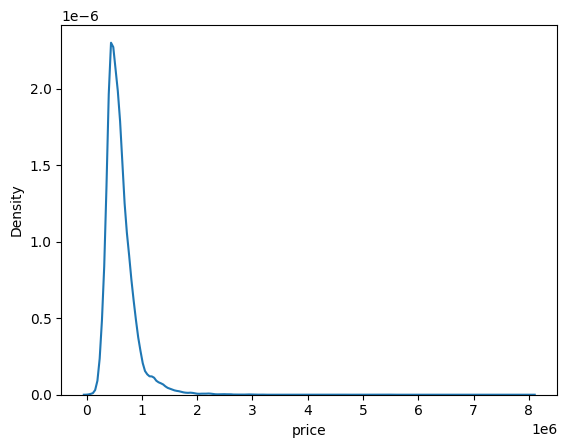

In [21]:
sns.kdeplot(df.price)

Upar diy gye data me normal skewness nahi hai.

Ab ham kuch transformations techniques use karenge taki unballanced skew data ko kuch normal skew form me la sake.

Ab niche hm kuch logarithmic funtions use arenge taki data kuch normal format me aa sake.

In [22]:
df['price_transformed'] = np.log(df.price)

In [23]:
df.price_transformed.skew()

np.float64(0.4731646269984763)

In [24]:
list_2 = find_anomalies(df.price_transformed)

In [25]:
len(list_2)

266

In [26]:
len(df)

29580

How to find anomaly(outlirs) = len(list_1) / len(df) * 100

anomaly = 266 / 29580 *100


anomaly = 0.9%

anomaly pahle se km hua hai

<Axes: xlabel='price_transformed', ylabel='Density'>

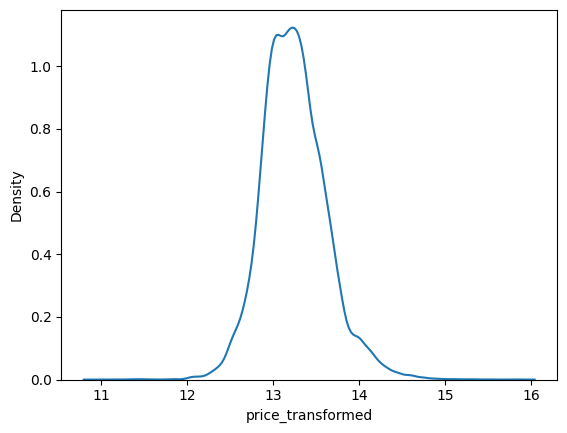

In [27]:
sns.kdeplot(df.price_transformed)

Phir se ek bar aur logarithmic funtions use kr dhekhenge.

In [28]:
df['price_transformed_double'] = np.log(df.price_transformed)

In [29]:
df['price_transformed_double'].skew()

np.float64(0.33092530655758573)

In [30]:
from matplotlib.cbook import file_requires_unicode
list_3 = find_anomalies(df.price_transformed_double)

In [31]:
len(list_3)

251

In [32]:
len(df)

29580

How to find anomaly(outlirs) = len(list_1) / len(df) * 100

anomaly = 251 / 29580 *100

anomaly = 0.8%

pahle se oulirs/skewness km hau hai.

1.94% -> 0.9% -> 0.8%

<Axes: ylabel='price'>

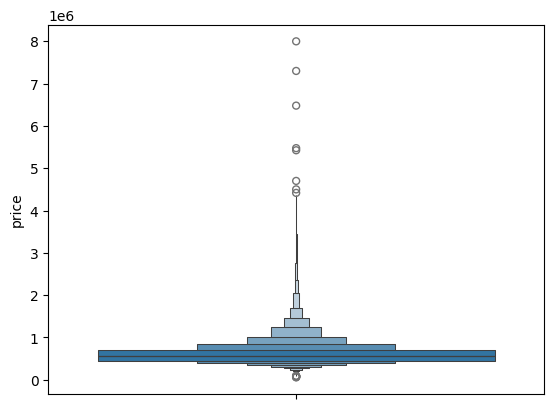

In [33]:
sns.boxenplot(y=df['price'])

Inter Quartile Range

IQR = Q3 - Q1


In [34]:
list1 = [43, 54, 56, 61, 62, 66, 68, 69, 69, 70, 71, 72, 77, 78, 79, 85, 87, 88, 89, 93, 95, 96, 98, 99, 99]


In [35]:
len(list1)


25

In [36]:
max(list1)

99

In [37]:
min(list1)

43

In [38]:
statistics.mean(list1)

76.96

In [39]:
sorted(list1)

[43,
 54,
 56,
 61,
 62,
 66,
 68,
 69,
 69,
 70,
 71,
 72,
 77,
 78,
 79,
 85,
 87,
 88,
 89,
 93,
 95,
 96,
 98,
 99,
 99]

In [40]:
list2 = sorted(list1)


In [41]:
list2

[43,
 54,
 56,
 61,
 62,
 66,
 68,
 69,
 69,
 70,
 71,
 72,
 77,
 78,
 79,
 85,
 87,
 88,
 89,
 93,
 95,
 96,
 98,
 99,
 99]

Hence, 98 is the 90th percentile for this dataset

Now say you want to find the 20th percentile. Start by taking 0.20 x 25 = 5 (the index); this is a whole number, which tells you the 20th percentile is the average of the 5th and 6th values in the ordered data set (62 and 66).

so, 20th percentile is 62+66/2 = 64

The median (the 50th percentile) for the test scores is the 13th score: 77.